# Noise in LJ trajectories in equilibrium


## Small noise diagnostic

This keeps the analysis intentionally small: sample fixed atom IDs from the local FCC/HCP/liquid dumps, estimate a 3D displacement distribution, test simple Gaussian diagnostics, and print the covariance matrix. FCC/HCP use displacement around each sampled atom's local mean position. The liquid has no stable lattice sites, so it uses frame-to-frame minimum-image increments by default.


,mode,n_frames,n_particles,n_vectors,anisotropy_ratio,alpha2_3d,mahalanobis_chi2_ks_p
label,,,,,,,
fcc,site,25,512,12800,1.053817,0.022873,0.207246
hcp,site,25,512,12800,1.078382,0.019717,0.103615
liquid,increments,25,512,12288,1.043410,0.001616,0.768215



FCC covariance (site displacements)


,x,y,z
x,0.005407,-0.000077,0.000108
y,-0.000077,0.005373,-0.000027
z,0.000108,-0.000027,0.005477


eigenvalues: [0.005579 0.005386 0.005294]
skew xyz: [ 1.539e-02 -3.266e-02 -3.729e-05]
excess kurtosis xyz: [0.045 0.031 0.111]

HCP covariance (site displacements)


,x,y,z
x,0.005390,0.000112,0.000035
y,0.000112,0.005366,0.000091
z,0.000035,0.000091,0.005144


eigenvalues: [0.005512 0.005277 0.005112]
skew xyz: [ 0.046 -0.05  -0.03 ]
excess kurtosis xyz: [0.046 0.103 0.111]

LIQUID covariance (increments displacements)


,x,y,z
x,6.743309,-0.05337,0.116135
y,-0.053370,6.70131,0.061010
z,0.116135,0.06101,6.677380


eigenvalues: [6.831393 6.743427 6.547178]
skew xyz: [-0.019  0.    -0.005]
excess kurtosis xyz: [ 0.019 -0.014  0.027]


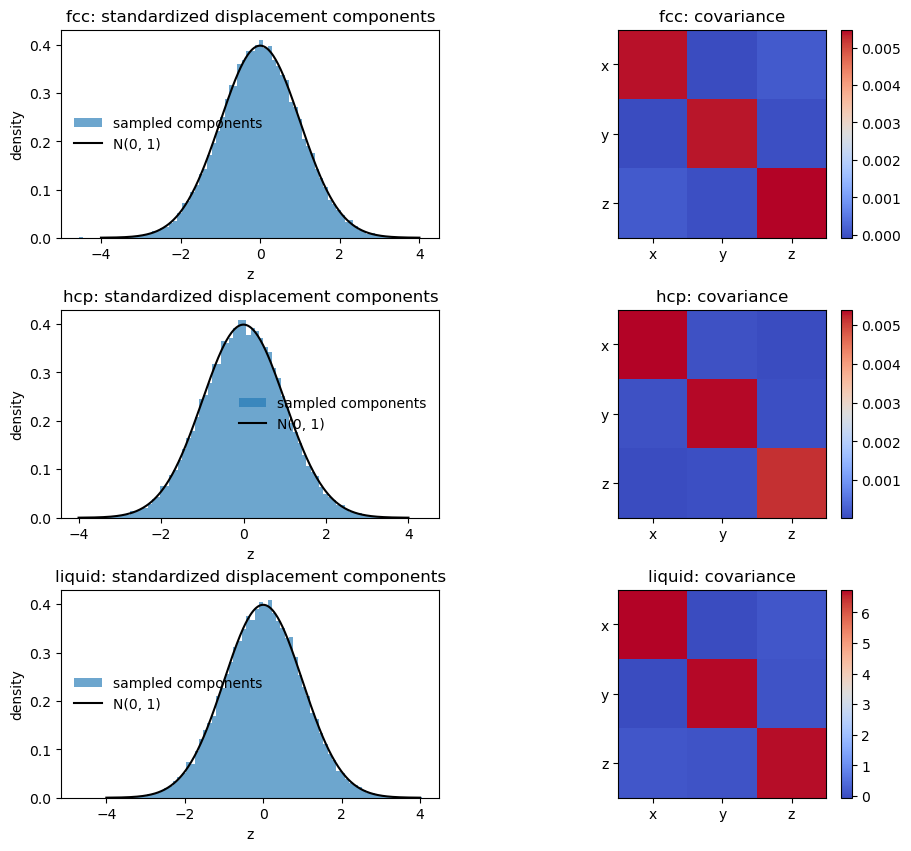

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import chi2, kstest, norm
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False


N_PARTICLES = 512
MAX_FRAMES = 25
FRAME_STRIDE = 1
SEED = 7


def find_data_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples",
        Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples").resolve(),
    ]
    for candidate in candidates:
        if (candidate / "fcc/traj.lammpstrj").exists():
            return candidate
    raise FileNotFoundError("Could not locate statistically_independent_samples data directory.")


DATA_DIR = find_data_dir()
TRAJECTORIES = {
    "fcc": DATA_DIR / "fcc/traj.lammpstrj",
    "hcp": DATA_DIR / "hcp/traj.lammpstrj",
    "liquid": DATA_DIR / "liquid/trajectory1.lammpstrj",
}
MODES = {"fcc": "site", "hcp": "site", "liquid": "increments"}


def _coord_columns(atom_columns):
    if {"xs", "ys", "zs"}.issubset(atom_columns):
        return [atom_columns.index(c) for c in ("xs", "ys", "zs")], True
    if {"x", "y", "z"}.issubset(atom_columns):
        return [atom_columns.index(c) for c in ("x", "y", "z")], False
    raise ValueError(f"No x/y/z or xs/ys/zs columns found in {atom_columns}.")


def read_sampled_lammpstrj(
    path,
    n_particles=N_PARTICLES,
    max_frames=MAX_FRAMES,
    frame_stride=FRAME_STRIDE,
    start_frame=0,
    seed=SEED,
    atom_ids=None,
):
    """Stream a small fixed-ID sample from a LAMMPS dump."""
    rng = np.random.default_rng(seed)
    selected_ids = None if atom_ids is None else np.asarray(atom_ids, dtype=np.int64)
    positions, boxes, timesteps = [], [], []

    with Path(path).open() as handle:
        frame_number = -1
        while len(positions) < max_frames:
            line = handle.readline()
            if not line:
                break
            if not line.startswith("ITEM: TIMESTEP"):
                raise ValueError(f"Expected ITEM: TIMESTEP, got {line.strip()!r} in {path}")

            frame_number += 1
            timestep = int(handle.readline())

            if not handle.readline().startswith("ITEM: NUMBER OF ATOMS"):
                raise ValueError("Malformed dump: missing atom-count header.")
            natoms = int(handle.readline())

            if not handle.readline().startswith("ITEM: BOX BOUNDS"):
                raise ValueError("Malformed dump: missing box header.")
            bounds = np.array([handle.readline().split()[:2] for _ in range(3)], dtype=float)
            lo = bounds[:, 0]
            box = bounds[:, 1] - bounds[:, 0]

            atom_columns = handle.readline().split()[2:]
            id_col = atom_columns.index("id")
            xyz_cols, scaled = _coord_columns(atom_columns)

            if selected_ids is None:
                n_take = min(int(n_particles), natoms)
                selected_ids = np.sort(rng.choice(np.arange(1, natoms + 1), size=n_take, replace=False))

            use_frame = frame_number >= start_frame and (frame_number - start_frame) % frame_stride == 0
            if not use_frame:
                for _ in range(natoms):
                    handle.readline()
                continue

            id_to_row = {int(atom_id): row for row, atom_id in enumerate(selected_ids)}
            frame = np.empty((len(selected_ids), 3), dtype=np.float64)
            found = 0
            for _ in range(natoms):
                fields = handle.readline().split()
                row = id_to_row.get(int(fields[id_col]))
                if row is None:
                    continue
                xyz = np.array([float(fields[col]) for col in xyz_cols], dtype=np.float64)
                frame[row] = lo + xyz * box if scaled else xyz
                found += 1

            if found != len(selected_ids):
                raise ValueError(f"Only found {found}/{len(selected_ids)} selected atoms in {path}.")
            positions.append(frame)
            boxes.append(box)
            timesteps.append(timestep)

    if len(positions) < 2:
        raise ValueError(f"Need at least two sampled frames from {path}.")
    return np.stack(positions), np.stack(boxes), np.asarray(timesteps), selected_ids


def minimum_image(delta, box):
    box = np.asarray(box, dtype=np.float64)
    if box.ndim == 1:
        return delta - box * np.round(delta / box)
    return delta - box[:, None, :] * np.round(delta / box[:, None, :])


def displacements_from_positions(positions, boxes, mode):
    if mode == "increments":
        disp = minimum_image(np.diff(positions, axis=0), boxes[1:])
    elif mode == "site":
        relative = minimum_image(positions - positions[0][None, :, :], boxes)
        local = positions[0][None, :, :] + relative
        disp = local - local.mean(axis=0, keepdims=True)
    else:
        raise ValueError("mode must be 'site' or 'increments'.")

    # Remove any global translation in each sampled frame.
    return disp - disp.mean(axis=1, keepdims=True)


def gaussian_noise_report(label, positions, boxes, timesteps, atom_ids, mode):
    disp = displacements_from_positions(positions, boxes, mode)
    flat = disp.reshape(-1, 3)
    flat = flat - flat.mean(axis=0, keepdims=True)

    covariance = np.cov(flat.T, bias=False)
    eigvals = np.linalg.eigvalsh(covariance)[::-1]
    anisotropy = eigvals[0] / max(eigvals[-1], np.finfo(float).eps)

    r2 = np.sum(flat**2, axis=1)
    alpha2 = 3.0 * np.mean(r2**2) / (5.0 * np.mean(r2) ** 2) - 1.0

    std = flat.std(axis=0, ddof=1)
    z = flat / std
    marginal_skew = np.mean(z**3, axis=0)
    marginal_excess_kurtosis = np.mean(z**4, axis=0) - 3.0

    report = {
        "label": label,
        "mode": mode,
        "n_frames": len(positions),
        "n_particles": len(atom_ids),
        "n_vectors": len(flat),
        "timestep_first": int(timesteps[0]),
        "timestep_last": int(timesteps[-1]),
        "covariance": covariance,
        "covariance_eigenvalues": eigvals,
        "anisotropy_ratio": anisotropy,
        "alpha2_3d": alpha2,
        "marginal_skew_xyz": marginal_skew,
        "marginal_excess_kurtosis_xyz": marginal_excess_kurtosis,
        "flat_displacements": flat,
    }

    if SCIPY_AVAILABLE:
        report["marginal_ks_p_xyz"] = np.array([kstest(z[:, i], norm.cdf).pvalue for i in range(3)])
        inv_cov = np.linalg.pinv(covariance)
        d2 = np.einsum("ni,ij,nj->n", flat, inv_cov, flat)
        report["mahalanobis_chi2_ks_p"] = kstest(d2, chi2(df=3).cdf).pvalue

    return report


def analyze_all():
    reports = {}
    for label, path in TRAJECTORIES.items():
        positions, boxes, timesteps, atom_ids = read_sampled_lammpstrj(path)
        reports[label] = gaussian_noise_report(
            label=label,
            positions=positions,
            boxes=boxes,
            timesteps=timesteps,
            atom_ids=atom_ids,
            mode=MODES[label],
        )
    return reports


reports = analyze_all()

summary_columns = [
    "label",
    "mode",
    "n_frames",
    "n_particles",
    "n_vectors",
    "anisotropy_ratio",
    "alpha2_3d",
]
summary = pd.DataFrame([{k: r[k] for k in summary_columns} for r in reports.values()]).set_index("label")
if SCIPY_AVAILABLE:
    summary["mahalanobis_chi2_ks_p"] = [r["mahalanobis_chi2_ks_p"] for r in reports.values()]
display(summary)

for label, report in reports.items():
    print(f"\n{label.upper()} covariance ({report['mode']} displacements)")
    display(pd.DataFrame(report["covariance"], index=list("xyz"), columns=list("xyz")))
    print("eigenvalues:", np.array2string(report["covariance_eigenvalues"], precision=6))
    print("skew xyz:", np.array2string(report["marginal_skew_xyz"], precision=3))
    print("excess kurtosis xyz:", np.array2string(report["marginal_excess_kurtosis_xyz"], precision=3))

fig, axes = plt.subplots(len(reports), 2, figsize=(9, 2.8 * len(reports)), constrained_layout=True)
xs = np.linspace(-4, 4, 400)
for row, (label, report) in enumerate(reports.items()):
    z = report["flat_displacements"] / report["flat_displacements"].std(axis=0, ddof=1)
    axes[row, 0].hist(z.ravel(), bins=80, density=True, alpha=0.65, label="sampled components")
    axes[row, 0].plot(xs, norm.pdf(xs), color="black", lw=1.5, label="N(0, 1)")
    axes[row, 0].set_title(f"{label}: standardized displacement components")
    axes[row, 0].set_xlabel("z")
    axes[row, 0].set_ylabel("density")
    axes[row, 0].legend(frameon=False)

    im = axes[row, 1].imshow(report["covariance"], cmap="coolwarm")
    axes[row, 1].set_title(f"{label}: covariance")
    axes[row, 1].set_xticks(range(3), list("xyz"))
    axes[row, 1].set_yticks(range(3), list("xyz"))
    fig.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
plt.show()


,n_frames,n_particles,pooled_ratio,median_particle_ratio,p90_particle_ratio,p99_particle_ratio,max_particle_ratio,frac_ratio_gt_1.25,frac_ratio_gt_1.50
label,,,,,,,,,
fcc,601,512,1.012938,1.187336,1.278570,1.379626,1.492623,0.177734,0.0
hcp,601,512,1.048579,1.189875,1.294382,1.395420,1.461751,0.214844,0.0



FCC median sampled particle: atom id 9995, anisotropy ratio 1.187
eigenvalues: [0.006024 0.005364 0.005074]


,x,y,z
x,0.005861,0.000294,-0.000034
y,0.000294,0.005433,-0.000165
z,-0.000034,-0.000165,0.005168



FCC most anisotropic sampled particle: atom id 25561, anisotropy ratio 1.493
eigenvalues: [0.006417 0.005532 0.004299]


,x,y,z
x,0.004937,0.000226,0.000904
y,0.000226,0.005454,-0.000225
z,0.000904,-0.000225,0.005857



HCP median sampled particle: atom id 25782, anisotropy ratio 1.190
eigenvalues: [0.005827 0.005509 0.004897]


,x,y,z
x,0.005297,-0.000182,0.000329
y,-0.000182,0.005737,0.000004
z,0.000329,0.000004,0.005199



HCP most anisotropic sampled particle: atom id 87826, anisotropy ratio 1.462
eigenvalues: [0.006475 0.005407 0.00443 ]


,x,y,z
x,0.005381,-0.000669,0.000449
y,-0.000669,0.006062,0.000199
z,0.000449,0.000199,0.004869


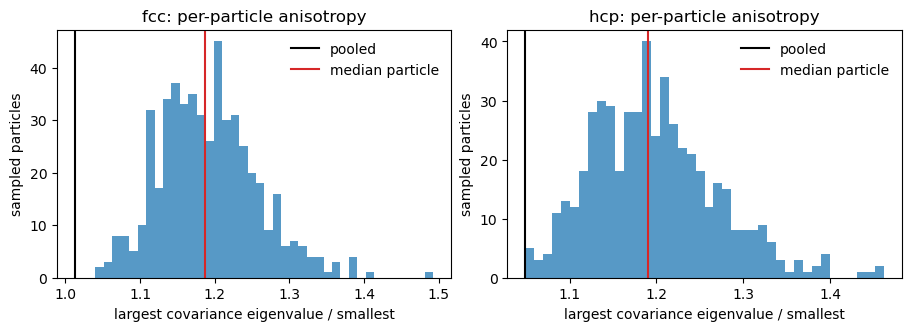

In [3]:
# Per-particle anisotropy check for the crystal trajectories only.
# This tests whether the pooled covariance above hides locally anisotropic cages.

CRYSTAL_LABELS = ("fcc", "hcp")
LOCAL_N_PARTICLES = 512
LOCAL_MAX_FRAMES = 601 
LOCAL_FRAME_STRIDE = 1


def per_particle_anisotropy_report(label):
    positions, boxes, timesteps, atom_ids = read_sampled_lammpstrj(
        TRAJECTORIES[label],
        n_particles=LOCAL_N_PARTICLES,
        max_frames=LOCAL_MAX_FRAMES,
        frame_stride=LOCAL_FRAME_STRIDE,
        seed=SEED,
    )
    disp = displacements_from_positions(positions, boxes, mode="site")

    # Center each particle's cloud before estimating that particle's covariance.
    local = disp - disp.mean(axis=0, keepdims=True)
    n_frames = local.shape[0]
    covs = np.einsum("tni,tnj->nij", local, local) / (n_frames - 1)

    eigvals = np.linalg.eigvalsh(covs)
    eigvals = np.sort(eigvals, axis=1)[:, ::-1]
    anisotropy = eigvals[:, 0] / np.maximum(eigvals[:, -1], np.finfo(float).eps)

    pooled = np.cov(local.reshape(-1, 3).T, bias=False)
    pooled_eigvals = np.linalg.eigvalsh(pooled)[::-1]
    pooled_anisotropy = pooled_eigvals[0] / pooled_eigvals[-1]

    strongest_idx = int(np.argmax(anisotropy))
    median_idx = int(np.argsort(anisotropy)[len(anisotropy) // 2])

    return {
        "label": label,
        "atom_ids": atom_ids,
        "timesteps": timesteps,
        "covariances": covs,
        "eigvals": eigvals,
        "anisotropy": anisotropy,
        "pooled_covariance": pooled,
        "pooled_eigvals": pooled_eigvals,
        "pooled_anisotropy": pooled_anisotropy,
        "strongest_idx": strongest_idx,
        "median_idx": median_idx,
        "n_frames": n_frames,
        "n_particles": len(atom_ids),
    }


local_reports = {label: per_particle_anisotropy_report(label) for label in CRYSTAL_LABELS}

local_summary = []
for label, report in local_reports.items():
    ratios = report["anisotropy"]
    local_summary.append({
        "label": label,
        "n_frames": report["n_frames"],
        "n_particles": report["n_particles"],
        "pooled_ratio": report["pooled_anisotropy"],
        "median_particle_ratio": np.median(ratios),
        "p90_particle_ratio": np.quantile(ratios, 0.90),
        "p99_particle_ratio": np.quantile(ratios, 0.99),
        "max_particle_ratio": np.max(ratios),
        "frac_ratio_gt_1.25": np.mean(ratios > 1.25),
        "frac_ratio_gt_1.50": np.mean(ratios > 1.50),
    })

local_summary = pd.DataFrame(local_summary).set_index("label")
display(local_summary)

for label, report in local_reports.items():
    for name, idx in [("median", report["median_idx"]), ("most anisotropic", report["strongest_idx"] )]:
        atom_id = int(report["atom_ids"][idx])
        ratio = report["anisotropy"][idx]
        print(f"\n{label.upper()} {name} sampled particle: atom id {atom_id}, anisotropy ratio {ratio:.3f}")
        print("eigenvalues:", np.array2string(report["eigvals"][idx], precision=6))
        display(pd.DataFrame(report["covariances"][idx], index=list("xyz"), columns=list("xyz")))

fig, axes = plt.subplots(1, len(local_reports), figsize=(9, 3.2), constrained_layout=True)
if len(local_reports) == 1:
    axes = [axes]
for ax, (label, report) in zip(axes, local_reports.items()):
    ratios = report["anisotropy"]
    ax.hist(ratios, bins=40, alpha=0.75)
    ax.axvline(report["pooled_anisotropy"], color="black", lw=1.5, label="pooled")
    ax.axvline(np.median(ratios), color="tab:red", lw=1.5, label="median particle")
    ax.set_title(f"{label}: per-particle anisotropy")
    ax.set_xlabel("largest covariance eigenvalue / smallest")
    ax.set_ylabel("sampled particles")
    ax.legend(frameon=False)
plt.show()


,true_motif_anisotropy,pooled_ratio,median_particle_ratio,p90_particle_ratio,p99_particle_ratio,max_particle_ratio,frac_ratio_gt_1.25,frac_ratio_gt_1.50
case,,,,,,,,
fcc isotropic,1.0,1.004427,1.177635,1.262066,1.330205,1.464426,0.152344,0.0
hcp isotropic,1.0,1.004427,1.177635,1.262066,1.330205,1.464426,0.152344,0.0
fcc motif 1.5,1.5,1.229980,2.278875,2.517346,2.714856,2.789231,1.000000,1.0
hcp motif 1.5,1.5,1.229980,2.278875,2.517346,2.714856,2.789231,1.000000,1.0


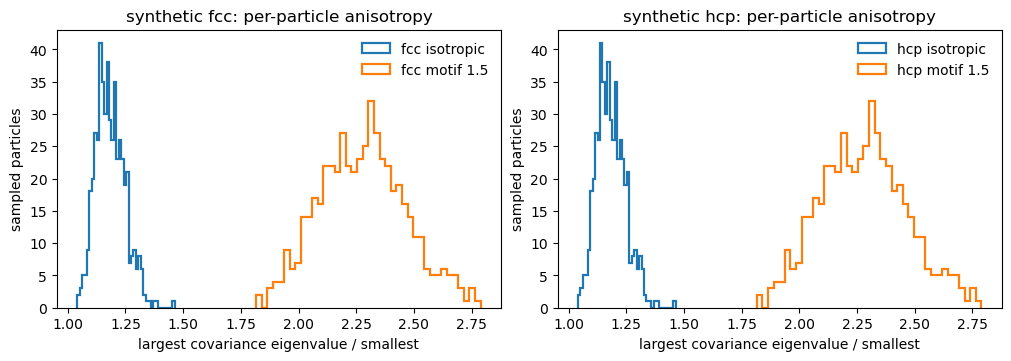

In [4]:
# Synthetic Gaussian control: perfect lattice + known Gaussian displacement motif.
# Use this to calibrate how much per-particle anisotropy is produced by finite sampling alone.

SYNTHETIC_FRAMES = 601
SYNTHETIC_SEED = 11


def make_perfect_lattice(kind="fcc", cells=(8, 8, 8), a=1.0, c_over_a=np.sqrt(8.0 / 3.0)):
    """Return positions, orthorhombic box lengths, and basis ids for a perfect FCC/HCP lattice."""
    kind = kind.lower()
    nx, ny, nz = map(int, cells)

    if kind == "fcc":
        cell = np.array([a, a, a], dtype=float)
        basis = a * np.array([
            [0.0, 0.0, 0.0],
            [0.0, 0.5, 0.5],
            [0.5, 0.0, 0.5],
            [0.5, 0.5, 0.0],
        ])
    elif kind == "hcp":
        c = c_over_a * a
        cell = np.array([a, np.sqrt(3.0) * a, c], dtype=float)
        basis = np.array([
            [0.0, 0.0, 0.0],
            [0.5 * a, 0.5 * np.sqrt(3.0) * a, 0.0],
            [0.5 * a, np.sqrt(3.0) * a / 6.0, 0.5 * c],
            [0.0, 2.0 * np.sqrt(3.0) * a / 3.0, 0.5 * c],
        ], dtype=float)
    else:
        raise ValueError("kind must be 'fcc' or 'hcp'.")

    positions = []
    basis_ids = []
    for ix in range(nx):
        for iy in range(ny):
            for iz in range(nz):
                origin = np.array([ix, iy, iz], dtype=float) * cell
                for basis_id, basis_pos in enumerate(basis):
                    positions.append(origin + basis_pos)
                    basis_ids.append(basis_id)

    return np.asarray(positions), np.array([nx, ny, nz], dtype=float) * cell, np.asarray(basis_ids)


def make_gaussian_motif_covariances(kind, sigma=0.073, anisotropy=1.0):
    """Return one 3x3 covariance per lattice-basis motif site."""
    n_basis = 4
    base = sigma**2 * np.eye(3)
    if anisotropy == 1.0:
        return np.repeat(base[None, :, :], n_basis, axis=0)

    # Same eigenvalues, but different principal axes for different basis sites.
    eig = sigma**2 * np.diag([anisotropy, 1.0, 1.0 / anisotropy])
    rotations = [
        np.eye(3),
        np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1]], dtype=float),
        np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]], dtype=float),
        np.array([[1, 0, 0], [0, 0, 1], [0, 1, 0]], dtype=float),
    ]
    return np.stack([R @ eig @ R.T for R in rotations], axis=0)


def add_gaussian_motif_noise(lattice_positions, box, basis_ids, motif_covariances, n_frames=601, seed=0):
    """Generate wrapped trajectory frames from exact Gaussian noise around lattice positions."""
    rng = np.random.default_rng(seed)
    lattice_positions = np.asarray(lattice_positions, dtype=float)
    box = np.asarray(box, dtype=float)
    cov_by_particle = motif_covariances[np.asarray(basis_ids, dtype=int)]

    frames = np.empty((n_frames, len(lattice_positions), 3), dtype=float)
    for frame in range(n_frames):
        noise = np.stack([rng.multivariate_normal(np.zeros(3), cov) for cov in cov_by_particle])
        noise -= noise.mean(axis=0, keepdims=True)
        frames[frame] = (lattice_positions + noise) % box
    return frames


def synthetic_per_particle_report(kind="fcc", anisotropy=1.0, n_particles=512, n_frames=SYNTHETIC_FRAMES):
    lattice, box, basis_ids = make_perfect_lattice(kind=kind, cells=(8, 8, 8), a=1.0)
    covs = make_gaussian_motif_covariances(kind=kind, sigma=0.073, anisotropy=anisotropy)
    positions = add_gaussian_motif_noise(lattice, box, basis_ids, covs, n_frames=n_frames, seed=SYNTHETIC_SEED)

    rng = np.random.default_rng(SEED)
    picked = np.sort(rng.choice(len(lattice), size=min(n_particles, len(lattice)), replace=False))
    sampled_positions = positions[:, picked, :]
    sampled_boxes = np.repeat(box[None, :], n_frames, axis=0)

    disp = displacements_from_positions(sampled_positions, sampled_boxes, mode="site")
    local = disp - disp.mean(axis=0, keepdims=True)
    local_covs = np.einsum("tni,tnj->nij", local, local) / (n_frames - 1)
    eigvals = np.linalg.eigvalsh(local_covs)
    eigvals = np.sort(eigvals, axis=1)[:, ::-1]
    ratios = eigvals[:, 0] / np.maximum(eigvals[:, -1], np.finfo(float).eps)

    pooled_cov = np.cov(local.reshape(-1, 3).T, bias=False)
    pooled_eigvals = np.linalg.eigvalsh(pooled_cov)[::-1]
    pooled_ratio = pooled_eigvals[0] / pooled_eigvals[-1]

    return {
        "kind": kind,
        "true_motif_anisotropy": anisotropy,
        "n_frames": n_frames,
        "n_particles": len(picked),
        "ratios": ratios,
        "pooled_ratio": pooled_ratio,
        "pooled_covariance": pooled_cov,
    }


synthetic_reports = {
    "fcc isotropic": synthetic_per_particle_report("fcc", anisotropy=1.0),
    "hcp isotropic": synthetic_per_particle_report("hcp", anisotropy=1.0),
    "fcc motif 1.5": synthetic_per_particle_report("fcc", anisotropy=1.5),
    "hcp motif 1.5": synthetic_per_particle_report("hcp", anisotropy=1.5),
}

synthetic_summary = []
for name, report in synthetic_reports.items():
    ratios = report["ratios"]
    synthetic_summary.append({
        "case": name,
        "true_motif_anisotropy": report["true_motif_anisotropy"],
        "pooled_ratio": report["pooled_ratio"],
        "median_particle_ratio": np.median(ratios),
        "p90_particle_ratio": np.quantile(ratios, 0.90),
        "p99_particle_ratio": np.quantile(ratios, 0.99),
        "max_particle_ratio": np.max(ratios),
        "frac_ratio_gt_1.25": np.mean(ratios > 1.25),
        "frac_ratio_gt_1.50": np.mean(ratios > 1.50),
    })
synthetic_summary = pd.DataFrame(synthetic_summary).set_index("case")
display(synthetic_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for ax, kind in zip(axes, ("fcc", "hcp")):
    for name, report in synthetic_reports.items():
        if not name.startswith(kind):
            continue
        ax.hist(report["ratios"], bins=40, histtype="step", lw=1.6, label=name)
    ax.set_title(f"synthetic {kind}: per-particle anisotropy")
    ax.set_xlabel("largest covariance eigenvalue / smallest")
    ax.set_ylabel("sampled particles")
    ax.legend(frameon=False)
plt.show()
